# The first approach to any EDA process is to understand the table content and structure

### Target tables:

- SalesOrderHeader: financial focuses on revenue, orders, dates and customers
- SalesOrderDetails: financial focuses in line items, products, quantities, prices
- Product: financial focuses on Products, prices and costs
- Employee: human focuses on employees, managers, hire dates, salaries
- Customer: human focuses on Customers, territories, demographics

### these tables focuses on extracting potentional `human-centered` and `financial` insights for the business direct and indirect benefit
- it appears I would require more tables to extract real insights, the sheer value and scale of this database is both rich and massive, I underestimated time required to do so, whereby the sales section connect with product, customers, spatial data. thus the viable option is to add tables as needed to deliver a quality summary of generated insights

In [113]:
import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from urllib.parse import quote_plus
from sqlalchemy import create_engine

load_dotenv()

db_user = os.getenv('DB_USER')
db_host = os.getenv('DB_HOST')
encoded_password = quote_plus(os.getenv('DB_PASSWORD'))
encoded_name = quote_plus(os.getenv('DB_NAME'))

connection_string = f'mysql+pymysql://{db_user}:{encoded_password}@{db_host}/{encoded_name}'
engine = create_engine(connection_string)

with engine.connect() as connection:
    
    # extracting salesorderheader table
    query_orderheader = 'SELECT * FROM `aw2022-sales-salesorderheader`'
    df_orderheader = pd.read_sql_query(query_orderheader, connection)

    # extracting salesorderdetails table
    query_orderdetails = 'SELECT * FROM `aw2022-sales-salesorderdetails`'
    df_orderdetails = pd.read_sql_query(query_orderdetails, connection)

    # extracting shipment method
    query_shipment = 'SELECT * FROM `aw2022-purchasing-shipmethod`'
    df_shipment = pd.read_sql_query(query_shipment, connection)

## A robust query design must:

- save sensitive variables in .env
- encode strings before reaching the DB connection string
- include a parameter dictionary as a guardrail against SQL injection
- align with business goals as to not overengineer the task and overcomplicate it

### for our case, we wouldn't include the third option as we are handling manual EDA and not an automated pipeline for a live service

In [114]:
df_orderheader.head(3)

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,CreditCardID,CreditCardApprovalCode,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,Comment,rowguid,ModifiedDate
0,43659,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43659,PO522145787,10-4020-000676,...,16281.0,105041Vi84182,NaN,20565.6206,1971.5149,616.0984,23153.2339,None,{79B65321-39CA-4115-9CBA-8FE0903E12E6},2011-06-07
1,43660,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43660,PO18850127500,10-4020-000117,...,5618.0,115213Vi29411,NaN,1294.2529,124.2483,38.8276,1457.3288,None,{738DC42D-D03B-48A1-9822-F95A67EA7389},2011-06-07
2,43661,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43661,PO18473189620,10-4020-000442,...,1346.0,85274Vi6854,4.0,32726.4786,3153.7696,985.5530,36865.8012,None,{D91B9131-18A4-4A11-BC3A-90B6F53E9D74},2011-06-07


In [115]:
df_orderheader.shape

(31465, 26)

In [116]:
df_orderheader.describe()

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,CustomerID,SalesPersonID,TerritoryID,BillToaddressID,ShipToAddressID,ShipMethodID,CreditCardID,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,ModifiedDate
count,31465.000000,31465.000000,31465,31465,31465,31465.0,31465.000000,3806.000000,31465.000000,31465.000000,31465.000000,31465.000000,30334.000000,13976.000000,31465.000000,31465.000000,31465.000000,31465.000000,31465
mean,59391.000000,8.000953,2013-08-21 11:43:49.321468,2013-09-02 11:44:14.034641,2013-08-28 11:44:14.034641,5.0,20170.175687,280.607987,6.090768,18263.154426,18249.192563,1.483839,9684.100448,9191.499571,3491.065673,323.755743,101.173693,3915.995109,2013-08-28 11:44:14.034641
min,43659.000000,8.000000,2011-05-31 00:00:00,2011-06-12 00:00:00,2011-06-07 00:00:00,5.0,11000.000000,274.000000,1.000000,405.000000,9.000000,1.000000,1.000000,2.000000,1.374000,0.109900,0.034400,1.518300,2011-06-07 00:00:00
25%,51525.000000,8.000000,2013-06-20 00:00:00,2013-07-02 00:00:00,2013-06-27 00:00:00,5.0,14432.000000,277.000000,4.000000,14080.000000,14063.000000,1.000000,4894.250000,8510.000000,56.970000,4.557600,1.424300,62.951900,2013-06-27 00:00:00
50%,59391.000000,8.000000,2013-11-03 00:00:00,2013-11-15 00:00:00,2013-11-10 00:00:00,5.0,19452.000000,279.000000,6.000000,19449.000000,19438.000000,1.000000,9719.500000,10074.000000,782.990000,62.639200,19.574800,865.204000,2013-11-10 00:00:00
75%,67257.000000,8.000000,2014-02-28 00:00:00,2014-03-13 00:00:00,2014-03-08 00:00:00,5.0,25994.000000,284.000000,9.000000,24678.000000,24672.000000,1.000000,14510.750000,11282.000000,2366.960000,189.597600,59.249300,2615.490800,2014-03-08 00:00:00
max,75123.000000,9.000000,2014-06-30 00:00:00,2014-07-12 00:00:00,2014-07-07 00:00:00,5.0,30118.000000,290.000000,10.000000,29883.000000,29883.000000,5.000000,19237.000000,12431.000000,163930.394300,17948.518600,5608.912100,187487.825000,2014-07-07 00:00:00
std,9083.307446,0.030864,NaN,NaN,NaN,0.0,6261.728960,4.846965,2.958119,8210.069158,8218.429263,1.304343,5566.299591,2945.170095,11093.452536,1085.054180,339.079427,12515.462713,NaN


In [117]:
df_orderheader.info()

<class 'pandas.DataFrame'>
RangeIndex: 31465 entries, 0 to 31464
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   SalesOrderID            31465 non-null  int64         
 1   RevisionNumber          31465 non-null  int64         
 2   OrderDate               31465 non-null  datetime64[us]
 3   DueDate                 31465 non-null  datetime64[us]
 4   ShipDate                31465 non-null  datetime64[us]
 5   Status                  31465 non-null  int64         
 6   OnlineOrderFlag         31465 non-null  str           
 7   SalesOrderNumber        31465 non-null  str           
 8   PurchaseOrderNumber     3806 non-null   str           
 9   AccountNumber           31465 non-null  str           
 10  CustomerID              31465 non-null  int64         
 11  SalesPersonID           3806 non-null   float64       
 12  TerritoryID             31465 non-null  int64         
 1

## it appears the next columns contain non-null values:

- `PurchaseOrderNumber`
- `SalesPersonID`
- `CreditCardID`
- `CreditCardApprovalCode`
- `CurrencyRateID`

In [118]:
def nan_count(column):
    ''' a function that returns the count of nan values for different columns'''
    nan = 0
    non_nan = 0

    for i in df_orderheader[column].isna():
        if i == True:
            nan += 1
        elif i == False:
            non_nan += 1

    return nan, non_nan

for i in df_orderheader.columns:
    nan, non_nan = nan_count(i)
    total = nan + non_nan

    if total == 0 or nan == 0:
        continue

    ratio = nan / total

    print(f'{i}, nan_ratio: {ratio*100:.2f}%')

PurchaseOrderNumber, nan_ratio: 87.90%
SalesPersonID, nan_ratio: 87.90%
CreditCardID, nan_ratio: 3.59%
CreditCardApprovalCode, nan_ratio: 3.59%
CurrencyRateID, nan_ratio: 55.58%
Comment, nan_ratio: 100.00%


## Generated insights from nan_ratios:
- 88% missing values in `SalePersonID` and `PurchaseOrderNumber` allows to define an intial assumption that 88% of sales transactions were online orders
- 4% in `CreditCardID` and `CreditCardApprovalCode` means that 4% of orders were paid using cash or other paying mediums whereby a massive ratio of 96% of transactions were paid using a credit card
    - it interestingly align with our first insight whom assumes 88% of sales were online orders, we will calculate the `OnlineFlagRatio` to confirm this assumption
- for the `CurrencyRateID` column, it appears that almost 56% of transactions happened in the local market (domestic), whereby almost 44% happened in internal or foreign markets

In [119]:
true, false = df_orderheader['OnlineOrderFlag'].value_counts()

true_ratio = true / (true + false)
print(f'online_orders_ratio: {true_ratio*100:.2f}%')

online_orders_ratio: 87.90%


- Online Orders Ratio: 87.90%
- Conclusion: Our previous assumption is true; the vast majority of transactions were online orders

### in Explatory Data Analysis some columns must be `dropped` as they hold 0 to low value in the process
##### we might try to save some NaN records if the ratio of missing values are relatively low and can be propagated
- columns to be removed:
    - `Comment`: an empty column
    - `rowguid`: Global Unique Identifier, doesn't add value to the EDA step
    - `ModifiedData`: data entry's date of modification, doesn't add value
    - `CreditCardID`: sensitive data, doesn't hold any value to the EDA process
    - `CreditCardApproval`: sensitive data, doesn't contribute to the EDA process
- columns to be propagated:
    - None

In [120]:
columns_to_remove = ['Comment', 'rowguid', 'ModifiedDate', 'CreditCardID', 'CreditCardApprovalCode']
refined_df_orderheader = df_orderheader.drop(columns=columns_to_remove)

refined_df_orderheader.head()

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,SalesPersonID,TerritoryID,BillToaddressID,ShipToAddressID,ShipMethodID,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue
0,43659,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43659,PO522145787,10-4020-000676,...,279.0,5,985,985,5,NaN,20565.6206,1971.5149,616.0984,23153.2339
1,43660,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43660,PO18850127500,10-4020-000117,...,279.0,5,921,921,5,NaN,1294.2529,124.2483,38.8276,1457.3288
2,43661,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43661,PO18473189620,10-4020-000442,...,282.0,6,517,517,5,4.0,32726.4786,3153.7696,985.5530,36865.8012
3,43662,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43662,PO18444174044,10-4020-000227,...,282.0,6,482,482,5,4.0,28832.5289,2775.1646,867.2389,32474.9324
4,43663,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43663,PO18009186470,10-4020-000510,...,276.0,4,1073,1073,5,NaN,419.4589,40.2681,12.5838,472.3108


### at this step, the scope aimed to focus on aggregating Orders with higher transactions count and transactions sum, tracking and preparing to analyze customer behavior using unsupervised modeling techniques to build generative profiles
- it appears that we would need to track the customers whom placed these Orders to find the real insights, as it appears below a single transaction count per SalesOrderID represent a unique identifier per product defined by an automated system to track each unique order  
    - update: `CustomerID` was part of the table, that helped save time and helped switch the merge operation from `SalesOrderID` to `CustomerID`

In [ ]:
Transaction_count_per_account = (
    refined_df_orderheader.groupby('CustomerID')['SubTotal']
    .count()
    .reset_index()
    .rename(columns={'SubTotal': 'Transactions_count'})
)

Transaction_total_per_account = (
    refined_df_orderheader.groupby('CustomerID')['SubTotal']
    .sum()
    .reset_index()
    .rename(columns={'SubTotal': 'Transactions_total'})
)

SalesID_df = pd.merge(Transaction_total_per_account, Transaction_count_per_account, on='CustomerID')

top_transactions_count = SalesID_df.sort_values(ascending=False, by='Transactions_count')
top_transactions_total = SalesID_df.sort_values(ascending=False, by='Transactions_total')

top_transactions_total.head(30)

,CustomerID,Transactions_total,Transactions_count
18818,29818,877107.1923,12
18715,29715,853849.1795,12
18722,29722,841908.7707,12
19117,30117,816755.5763,12
18614,29614,799277.8950,12
18639,29639,787773.0438,12
18701,29701,746317.5293,8
18617,29617,740985.8338,12
18994,29994,730798.7139,12
18646,29646,727272.6493,12


In [122]:
low_paying_customers_count = np.mean(top_transactions_count['Transactions_count'].head(30))
high_paying_customers_count = np.mean(top_transactions_total['Transactions_count'].head(30))

print(f'Transactions frequency count for low paying customers: \n{low_paying_customers_count}\n\nTransactions frequency count for high paying customers: \n{high_paying_customers_count}')

Transactions frequency count for low paying customers: 
21.366666666666667

Transactions frequency count for high paying customers: 
10.0


In [123]:
low_paying_customers_total = np.mean(top_transactions_count['Transactions_total'].head(30))
high_paying_customers_total = np.mean(top_transactions_total['Transactions_total'].head(30))

print(f'Transactions total sum for low paying customers: \n{low_paying_customers_total}\n\nTransactions total sum for high paying customers: \n{high_paying_customers_total}')

Transactions total sum for low paying customers: 
1029.5259999999998

Transactions total sum for high paying customers: 
671496.2839066666


In [124]:
# low paying customers's Average Value per Order
low_p_customers_AOV = low_paying_customers_total / low_paying_customers_count

# high paying customers's Average Value per Order
high_p_customers_AOV = high_paying_customers_total / high_paying_customers_count

print(f'Transaction cost per order for low paying customers: \n{low_p_customers_AOV:.2f}\n\nTransaction cost per order for high paying customers: \n{high_p_customers_AOV:.2f}')

Transaction cost per order for low paying customers: 
48.18

Transaction cost per order for high paying customers: 
67149.63


- it appears that top_30 customers with lower transaction total sum have more than double frequency that of the top_30 high paying customers, outliers exist but the patterns are real:
    - on average, transaction count for top_30 low paying customers ~= 21 transactions, with an average total transaction cost of approximately **$1030**
        - transaction cost per order for low paying customers is approximately **$48**
    - on average, transactions count for top_30 high paying customers ~= 10 transactions, with an average total transaction cost of approximately **$671496**
        - transaction cost per order for high paying customers is approximately **$67150**

- this is but an initial approach, as this calculation introduces bias which might impact insight quality, We planned to manually categories customers based on certain thresholds which requires dropping outliers (which might represent our most important customers), furthermore using Gaussian Mixture Model with a full covariance respect the variation of these customers in comparison to DBSCAN which might fail to capture these outliers

#### before proceeding to the unsupervised modeling layer, we are going to confirm our claim about outlier existance

In [ ]:
x_sales = SalesID_df['Transactions_count']
y_sales = SalesID_df['Transactions_total']

plt.figure(figsize=(10, 8))

plt.scatter(x_sales, y_sales,
            s=50,
            linewidth=2,
            color='ciel')

plt.suptitle('Transactions frequency relation to the total cost spent in transactions')
plt.xlabel('Transactions count')
plt.ylabel('Transactions total cost')

plt.tight_layout()
plt.show()

In [161]:
plt.scatter?

Signature:
plt.scatter(
    x: 'float | ArrayLike',
    y: 'float | ArrayLike',
    s: 'float | ArrayLike | None' = None,
    c: 'ArrayLike | Sequence[ColorType] | ColorType | None' = None,
    *,
    marker: 'MarkerType | None' = None,
    cmap: 'str | Colormap | None' = None,
    norm: 'str | Normalize | None' = None,
    vmin: 'float | None' = None,
    vmax: 'float | None' = None,
    alpha: 'float | None' = None,
    linewidths: 'float | Sequence[float] | None' = None,
    edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None,
    colorizer: 'Colorizer | None' = None,
    plotnonfinite: 'bool' = False,
    data=None,
    **kwargs,
) -> 'PathCollection'
Docstring:
A scatter plot of *y* vs. *x* with varying marker size and/or color.

Parameters
----------
x, y : float or array-like, shape (n, )
    The data positions.

s : float or array-like, shape (n, ), optional
    The marker size in points**2 (typographic points are 1/72 in.).
    Default is ``rc

In [125]:
# calculating the taxratio before freight cost
refined_df_orderheader['TaxRatio%'] = np.round(refined_df_orderheader['TaxAmt'] / (refined_df_orderheader['SubTotal'] + refined_df_orderheader['TaxAmt'])*100, 2)

# calculating freight ratio from `TotalDue` for further analysis
refined_df_orderheader['FreightBurden%'] = np.round(refined_df_orderheader['Freight'] / (refined_df_orderheader['SubTotal'] + refined_df_orderheader['Freight']) * 100, 2)

refined_df_orderheader.head(3)

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,BillToaddressID,ShipToAddressID,ShipMethodID,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,TaxRatio%,FreightBurden%
0,43659,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43659,PO522145787,10-4020-000676,...,985,985,5,NaN,20565.6206,1971.5149,616.0984,23153.2339,8.75,2.91
1,43660,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43660,PO18850127500,10-4020-000117,...,921,921,5,NaN,1294.2529,124.2483,38.8276,1457.3288,8.76,2.91
2,43661,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43661,PO18473189620,10-4020-000442,...,517,517,5,4.0,32726.4786,3153.7696,985.5530,36865.8012,8.79,2.92


In [126]:
refined_df_orderheader['SubTotal'].describe()

count     31465.000000
mean       3491.065673
std       11093.452536
min           1.374000
25%          56.970000
50%         782.990000
75%        2366.960000
max      163930.394300
Name: SubTotal, dtype: float64

### the creation of `TaxRatio%` urge the need for more geographic data, as it appears although some subtotals are low on average yet with higher tax than much larger subtotal values
- further analysis in shipment interval can be considered as indirect cause of tax increase
- further spatial data needed to evaluate a more accurate description of tax differentiation
- perhaps low subtotal have a higher tax rate on average, or different market static taxes regardless of such, we will proceed to confirm this assumption

### we will start with the first hypothesis as to confirm if low subtotal shipments have a greater taxratio than bigger subtotal shipments, followed by freight cost impact on taxratio

In [127]:
min_val = refined_df_orderheader['SubTotal'].min()
max_val = refined_df_orderheader['SubTotal'].max()

q1 = refined_df_orderheader['SubTotal'].quantile(0.25)
q3 = refined_df_orderheader['SubTotal'].quantile(0.75)

categorized_labels = ['Low', 'Medium', 'High']
cohort_bins = [min_val, q1, q3, max_val]

# categorizing `SubTotal` costs into three categories to build the support our hypothesis
refined_df_orderheader['SubTotalCategorized'] =  pd.cut(refined_df_orderheader['SubTotal'],
                                        bins=cohort_bins,
                                        labels=categorized_labels,
                                        include_lowest=True)

refined_df_orderheader.head(3)

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,ShipToAddressID,ShipMethodID,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,TaxRatio%,FreightBurden%,SubTotalCategorized
0,43659,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43659,PO522145787,10-4020-000676,...,985,5,NaN,20565.6206,1971.5149,616.0984,23153.2339,8.75,2.91,High
1,43660,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43660,PO18850127500,10-4020-000117,...,921,5,NaN,1294.2529,124.2483,38.8276,1457.3288,8.76,2.91,Medium
2,43661,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43661,PO18473189620,10-4020-000442,...,517,5,4.0,32726.4786,3153.7696,985.5530,36865.8012,8.79,2.92,High


In [128]:
refined_df_orderheader[['CustomerID', 'SubTotal', 'TaxAmt', 'TotalDue', 'TaxRatio%', 'FreightBurden%', 'SubTotalCategorized']].head(1)

,CustomerID,SubTotal,TaxAmt,TotalDue,TaxRatio%,FreightBurden%,SubTotalCategorized
0,29825,20565.6206,1971.5149,23153.2339,8.75,2.91,High


- Calculating the time interval between `OrderDate`, `ShipDate` and `DueDate` to support further hypothesis validation

In [129]:
temp_view = refined_df_orderheader[['OrderDate', 'DueDate', 'ShipDate']]

temp_view.head(5)

,OrderDate,DueDate,ShipDate
0,2011-05-31,2011-06-12,2011-06-07
1,2011-05-31,2011-06-12,2011-06-07
2,2011-05-31,2011-06-12,2011-06-07
3,2011-05-31,2011-06-12,2011-06-07
4,2011-05-31,2011-06-12,2011-06-07


- for the original table in **MySQL** Database, it appears that the values follows this format `xx-xx-xx` but for the timestamps it follows the same `00:00:00` value, as it appear from now on we can rest assured and focus on dates instead

In [130]:
# Normalizing Dtypes from timedelta64 into datetime
refined_df_orderheader['ShipDate'] = pd.to_datetime(refined_df_orderheader['ShipDate'])
refined_df_orderheader['OrderDate'] = pd.to_datetime(refined_df_orderheader['OrderDate'])
refined_df_orderheader['DueDate'] = pd.to_datetime(refined_df_orderheader['DueDate'])

# omitting the 'days' and leaving the values as integers
refined_df_orderheader['TimeInterval_ship'] = (
    refined_df_orderheader['ShipDate'] - refined_df_orderheader['OrderDate']
    ).dt.days

refined_df_orderheader['TimeInterval_due'] = (
    refined_df_orderheader['DueDate'] - refined_df_orderheader['OrderDate']
    ).dt.days

# doesn't require .dt.days as we already handled it in previous the previous calculations
refined_df_orderheader['BufferTime'] = refined_df_orderheader['TimeInterval_due'] - refined_df_orderheader['TimeInterval_ship']

# copied the subset using .copy() as each time this subset is modified it appears that it confuses pandas,
# pandas isn't sure if you aim to alter this subset or the original dataframe.
time_interval_summary = refined_df_orderheader[['TimeInterval_ship', 'TimeInterval_due', 'BufferTime', 'TaxRatio%']].copy()

time_interval_summary.head(3)

,TimeInterval_ship,TimeInterval_due,BufferTime,TaxRatio%
0,7,12,5,8.75
1,7,12,5,8.76
2,7,12,5,8.79


In [131]:
time_interval_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 31465 entries, 0 to 31464
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TimeInterval_ship  31465 non-null  int64  
 1   TimeInterval_due   31465 non-null  int64  
 2   BufferTime         31465 non-null  int64  
 3   TaxRatio%          31465 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 983.4 KB


#### testing correlation strenght between `taxratio` and other selective features

In [132]:
correlation_matrix = time_interval_summary.corr()['TaxRatio%']

correlation_matrix

TimeInterval_ship    0.002025
TimeInterval_due     0.002025
BufferTime                NaN
TaxRatio%            1.000000
Name: TaxRatio%, dtype: float64

- it appeared, that `TimeInterval_ship` and `TimeInterval_due` doesn't correlate but a tiny fraction to `TaxRatio%` increase, we also notice that `BufferTime` returned **NaN**

In [133]:
for i in time_interval_summary['BufferTime'].unique():
    print(i)

5


In [134]:
np.var(time_interval_summary['BufferTime'])

np.float64(0.0)

### Operational Insight: Uniform Logistics Execution Across Tax zones:
- Finding: Statistical correlation between `BufferTime` and `TaxRatio` returned **Nan**, driven by total absense in the variance in the buffer window, with a single outlier of **5 days** in 31,465 transactions
- Conclusion: Fullfillment scheduling is entirely uniform. Regional tax rates differences has no impact on delivery expectation and logistics timeline

### Let's visualize the correlation matrix in our target table

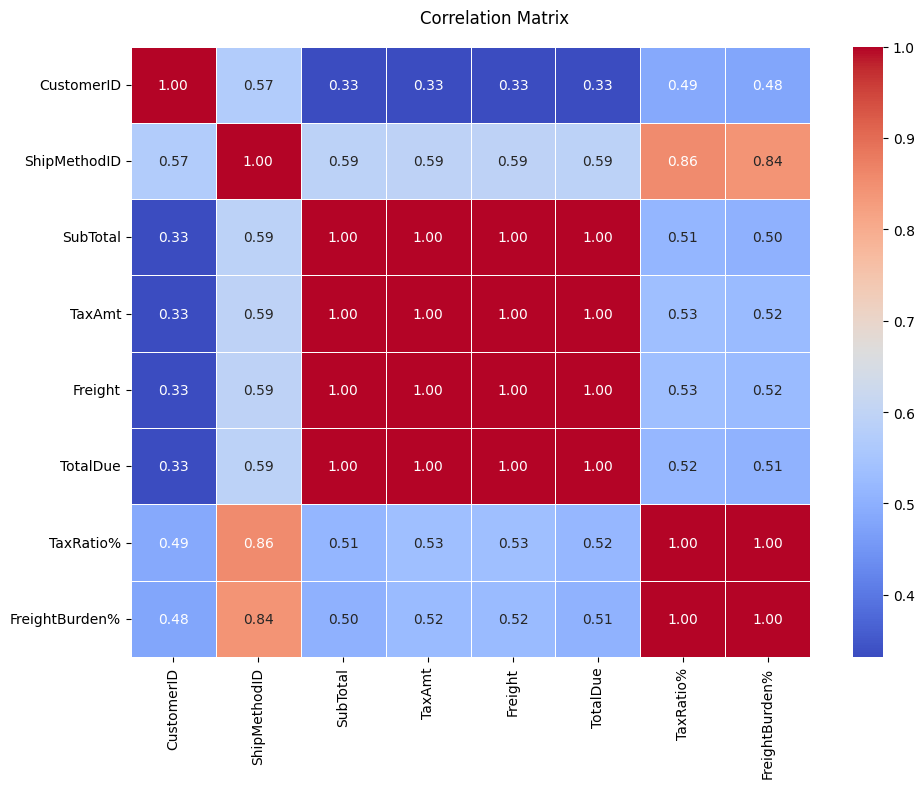

In [136]:
import seaborn as sns

temp_table = refined_df_orderheader.drop(columns=['OrderDate', 'DueDate', 'ShipDate', 'PurchaseOrderNumber', 'AccountNumber',
                                                'RevisionNumber', 'OnlineOrderFlag', 'SalesOrderNumber', 'SubTotalCategorized',
                                                'Status', 'BufferTime', 'SalesOrderID', 'TimeInterval_ship', 'TimeInterval_due',
                                                'BillToaddressID', 'ShipToAddressID', 'SalesPersonID', 'TerritoryID', 'CurrencyRateID']) # doesn't add much weight to the correlation strength

corr_matrix = temp_table.corr()
correlation_matrix

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidth=0.4)

plt.suptitle('Correlation Matrix')

plt.tight_layout()
plt.show()

- previously we calculated `TaxRatio%` of `TotalDue` without `FreightBurden%`, yet it appears they perfectly correlate in this visualization, and the reason behind such is both calculations relied on `SubTotal` as baseline to reach the cost ratio to TotalDue, even the original features confirm such with a perfect 1.00 correlation
- but I want you to look at `ShipMethodID` correlation with `TaxRatio%` and `FreightBurden%`, reflecting that these new added features are useful for further analysis with different Shipment Methods

- you are expected tomorrow to find corr() in the whole table, track back Orders `SalesOrderID` per product and customers, confirm this hypothesis:
    - perhaps low subtotal have a higher tax rate on average, or different market static taxes regardless of such, we will proceed to confirm this assumption
- and potentionally if possible visualize insights for non-technical audience